# Problemas de distribución de probabilidad

## Distribución binomial

En teoría de la probabilidad y estadística, la distribución binomial es la distribución de probabilidad discreta que da sólo dos resultados posibles en un experimento; por ejemplo, al lanzar una moneda, puede salir cara o cruz.

In [23]:
from scipy.stats import binom

# Definir todas las funciones de probabilidad relacionadas con esta distribución.

def dbinom(x, size, prob = 0.5):
    """
    Calcula la estimación puntual de la distribución binomial.
    """
    result = binom.pmf(k = x, n = size, p = prob, loc = 0)

    return result

def pbinom(q, size, prob = 0.5):
    """
    Calcula el acumulado de la distribución binomial.
    """
    result = binom.cdf(k = q, n = size, p = prob, loc = 0)

    return result

def qbinom(p, size, prob = 0.5):
    """
    Calcula la función cuantil a partir de la distribución binomial.
    """
    result = binom.ppf(q = p, n = size, p = prob, loc = 0)

    return result

def rbinom(n, size, prob = 0.5):
    """
    Genera variables aleatorias a partir de la distribución binomial.
    """
    result = binom.rvs(n = size, p = prob, size = n)

    return result

In [24]:
# Distribución binomial(10, 0.2), dónde n = 10 es el número de ensayos y p = 0.2 es la probabilidad de éxito en un solo ensayo
import numpy as np

np.random.seed(42)

print(f"Probability that a Binomial(10, 0.2) takes the value 2: {dbinom(2, size = 10, prob = 0.2)}")
print(f"Probability that a Binomial(10, 0.2) will take a value less than 2: {pbinom(2, size = 10, prob = 0.2)}")
print(f"Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? {qbinom(0.9, size = 10, prob = 0.2)}")
print(f"Generate 2000 random values from a Binomial(10, 0.2) distribution: {rbinom(2000, size = 10, prob = 0.2)}")

Probability that a Binomial(10, 0.2) takes the value 2: 0.30198988800000004
Probability that a Binomial(10, 0.2) will take a value less than 2: 0.6777995263999999
Which value of a Binomial(10, 0.2) has a cumulative probability of 0.9? 4.0
Generate 2000 random values from a Binomial(10, 0.2) distribution: [1 4 3 ... 0 0 1]


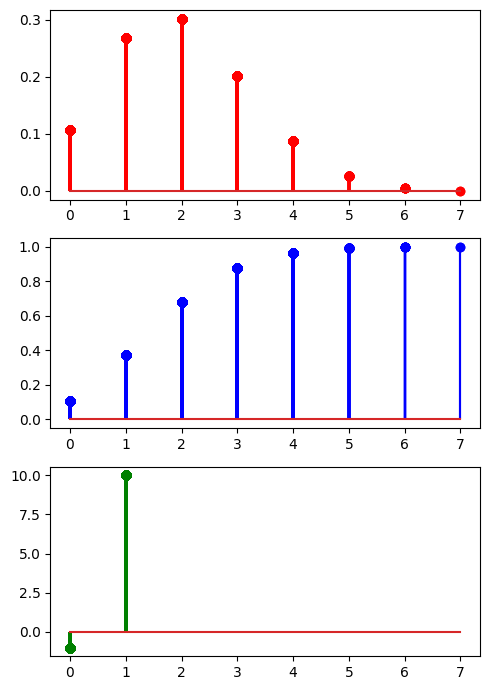

In [25]:
import matplotlib.pyplot as plt

np.random.seed(42)

size = 10
prob = 0.2
data = rbinom(2000, size = 10, prob = 0.2)

pmf = dbinom(data, size = size, prob = prob)
cdf = pbinom(data, size = size, prob = prob)
ppf = qbinom(data, size = size, prob = prob)

fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].stem(data, pmf, "r-")
axis[1].stem(data, cdf, "b-")
axis[2].stem(data, ppf, "g-")

# Adjust the layout
plt.tight_layout()

# Show the plot
plt.show()

## Ejercicio 1

Escriba las funciones anteriores pero para distribuciones normales y uniformes.

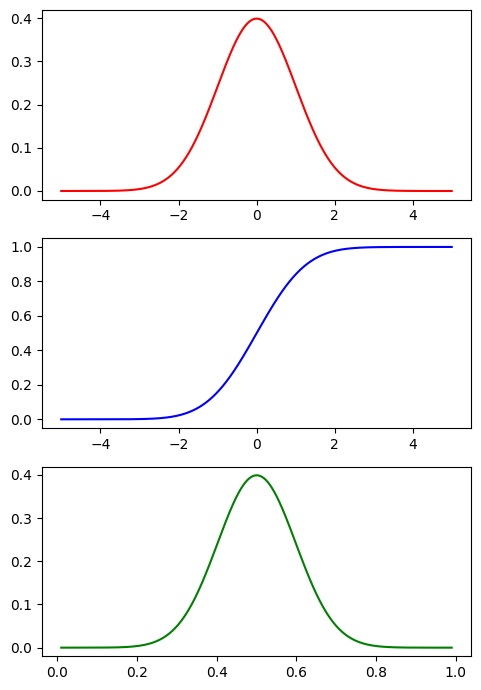

In [26]:
# Distribucion normal

from scipy.stats import norm

def dnorm(x, mean = 0, sd = 1):
    return norm.pdf(x, loc = mean, scale =sd)

def pnorm(q, mean = 0, sd = 1):
    return norm.cdf(q, loc = mean, scale = sd)

def qnorm(p, mean = 0, sd = 1):
    return norm.ppf(p, loc = mean, scale = sd)

def rnorm(n, mean = 0, sd =1):
    return norm.rvs(n, loc = mean, scale = sd)

import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

# parametros
mean = 0
sd = 1
data = np.arange(-5, 5, 0.01)
prob_arange = np.linspace(0.01, 0.99, len(data))

pmf = dnorm(data, mean = mean, sd = sd)
cdf = pnorm(data, mean = mean, sd = sd)
ppf = qnorm(prob_arange, mean = mean, sd=sd)

# graficos
fig, axis = plt.subplots(3, 1, figsize = (5, 7))

axis[0].plot(data, pmf, "r-")
axis[1].plot(data, cdf, "b-")
axis[2].plot(prob_arange, pmf, "g-")

plt.tight_layout()
plt.show()

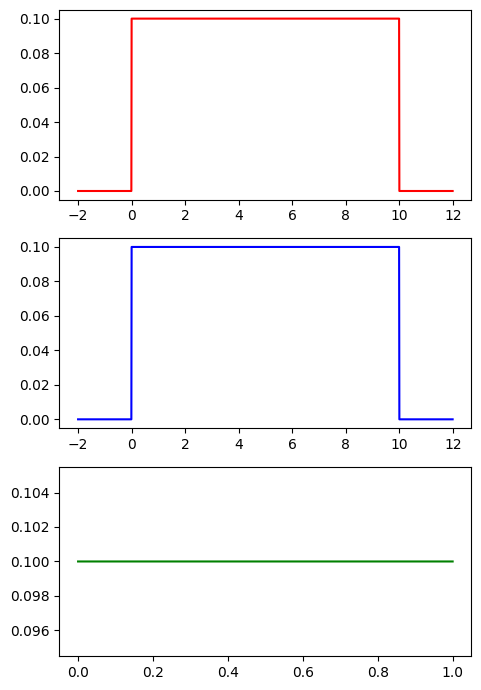

In [27]:
# Distribucion uniforme
from scipy.stats import uniform

def duniform(x, a = 0, b = 1):
    return uniform.pdf(x, loc = a, scale = b - a)

def puniform(q, a = 0, b = 1):
    return uniform.cdf(q, loc = a, scale = b - a)

def quniform(p, a = 0, b = 1):
    return uniform.ppf(p, loc = a, scale = b - a)

def runiform(n, a = 0, b = 1):
    return uniform.rvs(loc = a, scale = b - a, size = n)

import matplotlib.pyplot as plt
import numpy as np

# parametros
a = 0
b = 10
data_uni = np.arange(-2, 12, 0.01)
prob_arange = np.linspace(0, 1, len(data_uni))

pmf_u = duniform(data_uni, a = a, b = b)
cdf_u = duniform(data_uni, a = a, b = b)
ppf_u = duniform(prob_arange, a = a, b = b)

# graficos
fig, axis = plt.subplots(3, 1, figsize=(5, 7))

axis[0].plot(data_uni, pmf_u, "r-")
axis[1].plot(data_uni, cdf_u, "b-")
axis[2].plot(prob_arange, ppf_u, "g-")

plt.tight_layout()
plt.show()